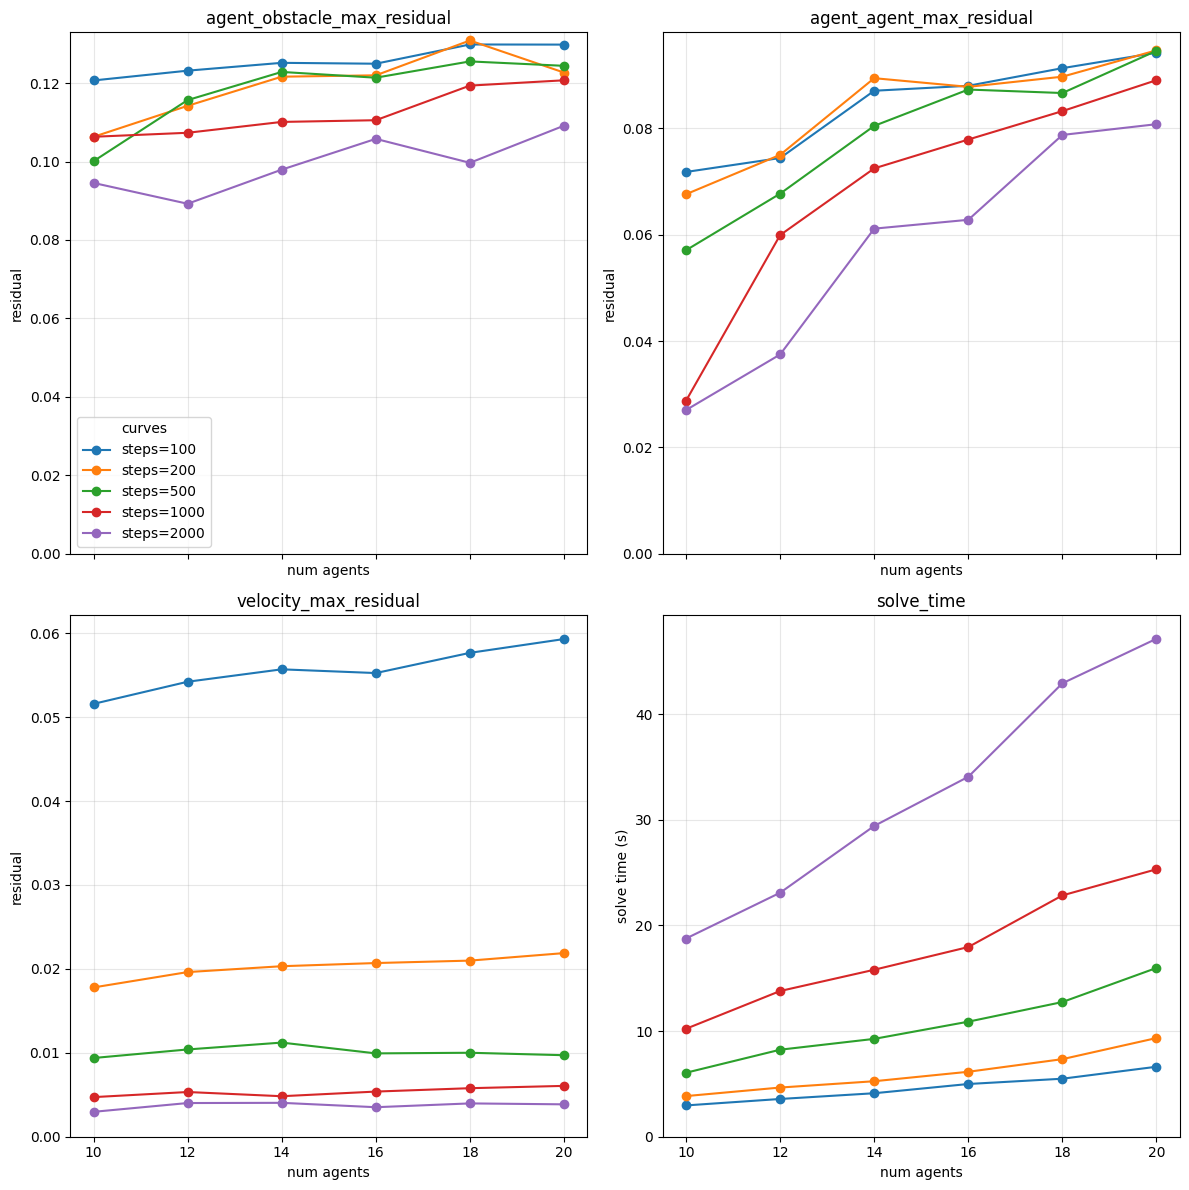

,num_agents,steps,agent_obstacle_max_residual,agent_agent_max_residual,velocity_max_residual,solve_time
0,10,100,0.120666,0.071814,0.051573,2.963266
1,12,100,0.123163,0.074437,0.054210,3.574235
2,14,100,0.125160,0.087095,0.055689,4.117137
3,16,100,0.124936,0.088027,0.055245,4.992420
4,18,100,0.129841,0.091342,0.057653,5.493010
5,20,100,0.129810,0.094249,0.059298,6.625920
6,10,200,0.106296,0.067626,0.017786,3.847883
7,12,200,0.114197,0.075032,0.019617,4.656165
8,14,200,0.121626,0.089457,0.020315,5.254385
9,16,200,0.121977,0.087828,0.020693,6.149691


In [4]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path("../results/2026-03-14/sweep_19-50-04_steps_and_agents")
pattern = re.compile(r"num_agents_(\d+)__steps_(\d+)")

records = []
for run_dir in sorted(root.glob("num_agents_*__steps_*")):
    match = pattern.fullmatch(run_dir.name)
    if not match:
        continue

    num_agents = int(match.group(1))
    steps = int(match.group(2))
    table_path = run_dir / "table.csv"
    if not table_path.exists():
        continue

    df = pd.read_csv(table_path)
    records.append(
        {
            "num_agents": num_agents,
            "steps": steps,
            "agent_obstacle_max_residual": df["agent_obstacle_max_residual"].mean(),
            "agent_agent_max_residual": df["agent_agent_max_residual"].mean(),
            "velocity_max_residual": df["velocity_max_residual"].mean(),
            "solve_time": df["solve_time"].mean(),
        }
    )

summary = (
    pd.DataFrame(records).sort_values(["steps", "num_agents"]).reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True)
residual_cols = [
    "agent_obstacle_max_residual",
    "agent_agent_max_residual",
    "velocity_max_residual",
    "solve_time",
]

for ax, residual_col in zip(axes.reshape(-1), residual_cols):
    for steps, group in summary.groupby("steps"):
        group = group.sort_values("num_agents")
        ax.plot(
            group["num_agents"],
            group[residual_col],
            marker="o",
            label=f"steps={steps}",
        )

    ax.set_title(residual_col)
    ax.set_xlabel("num agents")
    ax.set_ylabel("residual")
    ax.set_ylim(bottom=0)
    if residual_col == "solve_time":
        ax.set_ylabel("solve time (s)")
    ax.grid(alpha=0.3)

axes[0, 0].legend(title="curves")
fig.tight_layout()
plt.show()

summary

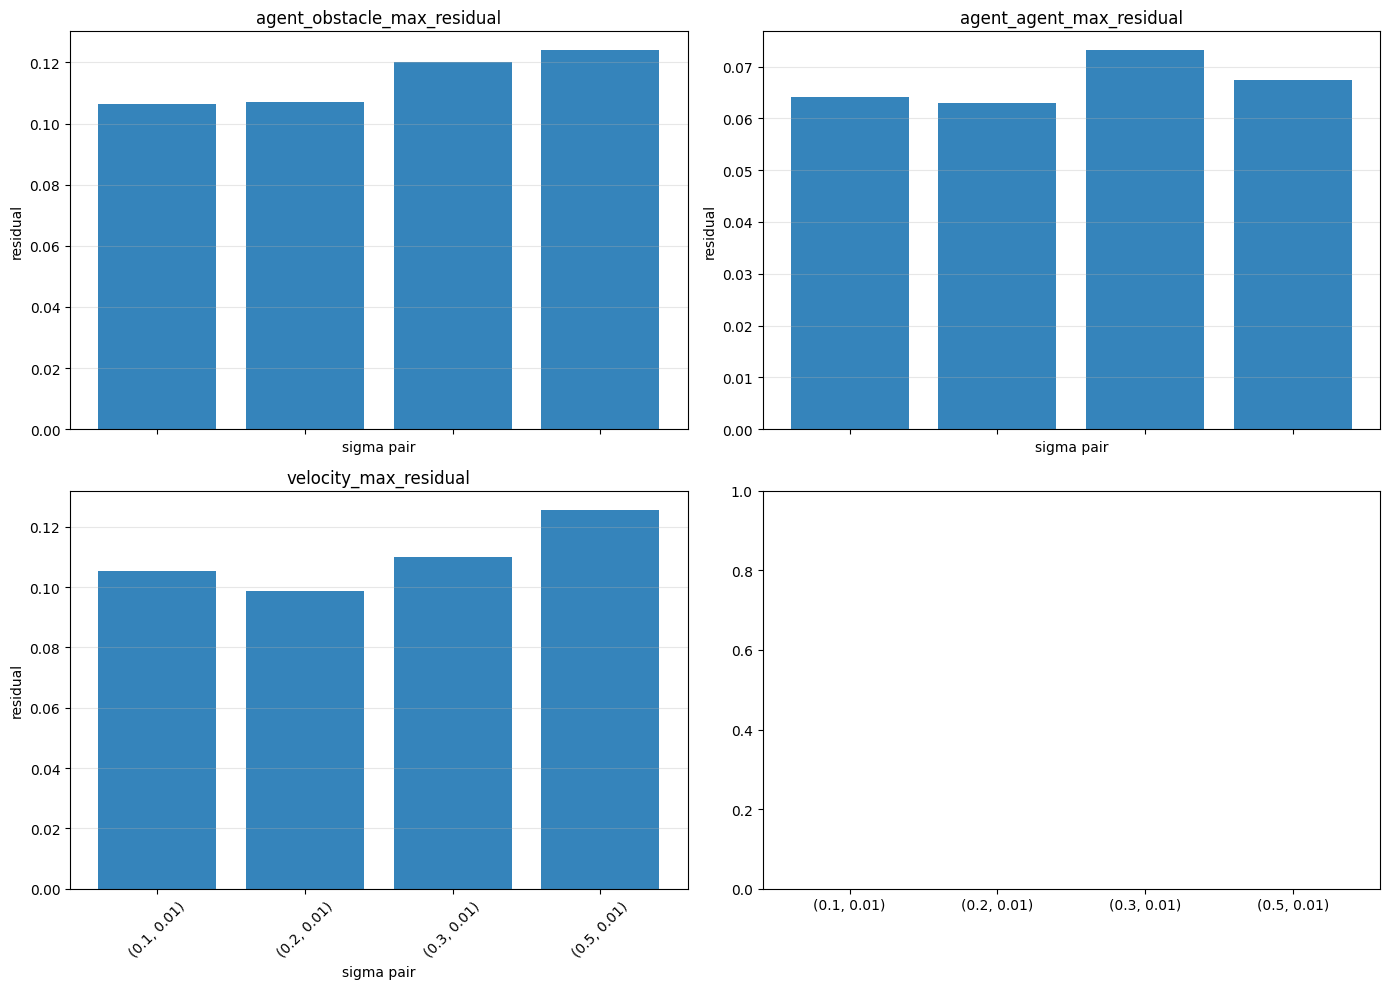

,sigma_pair,agent_obstacle_max_residual,agent_agent_max_residual,velocity_max_residual,sigma_pair_label
0,"(0.1, 0.01)",0.106532,0.064132,0.105450,"(0.1, 0.01)"
1,"(0.2, 0.01)",0.106991,0.062889,0.098621,"(0.2, 0.01)"
2,"(0.3, 0.01)",0.120016,0.073153,0.109818,"(0.3, 0.01)"
3,"(0.5, 0.01)",0.123980,0.067440,0.125613,"(0.5, 0.01)"


In [8]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path("../results/2026-03-14/sweep_20-21-23_sigma_range")
pattern = re.compile(
    r"init_sigma_(\d+\.?\d*)__end_sigma_(\d+\.?\d*)__steps_(\d+)__num_agents_(\d+)"
)

records = []
for run_dir in sorted(root.glob("init_*")):
    match = pattern.fullmatch(run_dir.name)
    if not match:
        continue

    init_sigma = float(match.group(1))
    end_sigma = float(match.group(2))
    table_path = run_dir / "table.csv"
    if not table_path.exists():
        continue

    df = pd.read_csv(table_path)
    records.append(
        {
            "sigma_pair": (init_sigma, end_sigma),
            "agent_obstacle_max_residual": df["agent_obstacle_max_residual"].mean(),
            "agent_agent_max_residual": df["agent_agent_max_residual"].mean(),
            "velocity_max_residual": df["velocity_max_residual"].mean(),
            "solve_time": df["solve_time"].mean(),
        }
    )

summary = pd.DataFrame(records)
plot_cols = [
    "agent_obstacle_max_residual",
    "agent_agent_max_residual",
    "velocity_max_residual",
    # "solve_time",
]

summary = (
    summary.groupby("sigma_pair", as_index=False)[plot_cols]
    .mean()
    .sort_values("sigma_pair")
    .reset_index(drop=True)
)
summary["sigma_pair_label"] = summary["sigma_pair"].map(
    lambda p: f"({p[0]:g}, {p[1]:g})"
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for ax, metric in zip(axes.reshape(-1), plot_cols):
    ax.bar(summary["sigma_pair_label"], summary[metric], alpha=0.9)
    ax.set_title(metric)
    ax.set_xlabel("sigma pair")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("solve time (s)" if metric == "solve_time" else "residual")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

summary